In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/sample_submission.csv
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/baseline_starter.py
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/metadata.csv
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/test/images/img_01518.png
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/test/images/img_01003.png
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/test/images/img_01370.png
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/test/images/img_02061.png
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/test/images/img_01902.png
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/test/images/img_01962.png
/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-

# Phase 1 -- Dataset Exploration

## Import Libraries 

In [2]:
import os 
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns 

from PIL import Image 
import cv2

from sklearn.model_selection import train_test_split

# Deep Learning
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

# Image Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

warnings.filterwarnings("ignore")

## About Semantic Segmentation 

> Semantic segmentation is a computer vision task in which every pixel of an image is assigned a semantic class label. Unlike image classification, which predicts a single label for the entire image, semantic segmentation produces a dense pixel-wise prediction, enabling the precise localization of different object categories.

Image segmentation is an end-to-end image analysis process that divides a digital image into multiple segments and classifies the information contained in each region.

The three are --
- Semantic segmentation
- Instance segmentation
- Panoptic segmentation

Whereas **semantic segmentation** labels every single pixel contained in an image by its semantic class, **instance segmentation** and **panoptic segmentation** are used for different classification tasks. As our NPPE is based on Semantic segmentation so we will concentrate on this only .

## Objective 

Build a computer vision system capable of performing pixel-level semantic segmentation and classification of six mechanical hardware components in cluttered RGB images.

## About the 6 Classes 

We are given RGB images, 384x384 pixels, of a workbench with mechanical fasteners scattered across it. For every pixel in each image, we must predict which of six part classes it belongs to.

The six classes and their pixel labels are:

| ID | Class | Appearance |
|----|----------------|------------------------------------------------------|
| 1  | `hex_nut`      | Six-sided outline, central hole, thick |
| 2  | `washer`       | Circular outline, central hole, thin and flat |
| 3  | `bolt`         | Hex head plus a threaded shank |
| 4  | `ball_bearing` | Solid sphere, bright highlight on top |
| 5  | `spring`       | Helical coil, repeating loops |
| 6  | `o_ring`       | Circular, round tube cross-section, matte |

## Dice Score 

The **Dice coefficient** (or Dice similarity coefficient) is a statistical metric used to gauge the overlap or similarity between two samples or sets. It ranges from 0 (no overlap) to 1 (perfect overlap).

So it will be used as the scoring factor in the submission as it will measure the overlap between your predicted mask and the ground truth. For a predicted pixel set X and a true pixel set Y ; 

`Dice (X,Y) = 2 · |X ∩ Y| / (|X| + |Y|)`

and the final score will be evaluated on the mean **Dice coefficient** where it will be the **mean value across all 3000 pairs (500 test images * 6 classes)**

---

## Information about the Dataset Directory structure 

In [3]:
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f"{subindent}{f}")


input/
    competitions/
        nppe-1-dl-gen-ai-course-semantic-segmentation/
            Dataset/
                sample_submission.csv
                baseline_starter.py
                metadata.csv
                test/
                    images/
                        img_01518.png
                        img_01003.png
                        img_01370.png
                        img_02061.png
                        img_01902.png
                train/
                    train.csv
                    images/
                        img_00464.png
                        img_00262.png
                        img_01965.png
                        img_00312.png
                        img_01601.png
                    masks/
                        img_00464.png
                        img_00262.png
                        img_01965.png
                        img_00312.png
                        img_01601.png


In [4]:
DATASET_PATH = "/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset"

TRAIN_IMAGE_PATH = os.path.join(DATASET_PATH, "train/images")
TRAIN_MASK_PATH = os.path.join(DATASET_PATH, "train/masks")
TEST_IMAGE_PATH = os.path.join(DATASET_PATH, "test/images")

## Load Metadata dataset and sample_submission 

In [5]:
metadata  = pd.read_csv("/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/metadata.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset/sample_submission.csv")

### Information about the metadata of the all datasets

In [6]:
display(metadata.head())

print(f"\nDataset Shape : {metadata.shape}")
print(f"Training Images : {(metadata['split']=='train').sum()}")
print(f"Testing Images : {(metadata['split']=='test').sum()}\n")

display(metadata.info())

,id,split,background,n_parts,classes_present
0,img_00000.png,train,wood,10.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring
1,img_00001.png,test,NaN,NaN,NaN
2,img_00002.png,train,concrete,10.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring
3,img_00003.png,train,concrete,7.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring
4,img_00004.png,train,concrete,6.0,hex_nut;washer;bolt;ball_bearing;spring;o_ring



Dataset Shape : (2500, 5)
Training Images : 2000
Testing Images : 500

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2500 non-null   object 
 1   split            2500 non-null   object 
 2   background       2000 non-null   object 
 3   n_parts          2000 non-null   float64
 4   classes_present  2000 non-null   object 
dtypes: float64(1), object(4)
memory usage: 97.8+ KB


None

In [7]:
print(f"Dataset Shape : {metadata.shape}")
print(f"Training Images : {(metadata['split']=='train').sum()}")
print(f"Testing Images : {(metadata['split']=='test').sum()}\n")

metadata.info()

Dataset Shape : (2500, 5)
Training Images : 2000
Testing Images : 500

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2500 non-null   object 
 1   split            2500 non-null   object 
 2   background       2000 non-null   object 
 3   n_parts          2000 non-null   float64
 4   classes_present  2000 non-null   object 
dtypes: float64(1), object(4)
memory usage: 97.8+ KB


In [8]:
display(metadata.describe())

print(f"\nAverage Parts per Image   : {metadata['n_parts'].mean():.2f}")
print(f"Minimum Parts             : {metadata['n_parts'].min():.0f}")
print(f"Maximum Parts             : {metadata['n_parts'].max():.0f}")

,n_parts
count,2000.000000
mean,8.456500
std,1.526195
min,6.000000
25%,7.000000
50%,8.000000
75%,10.000000
max,11.000000



Average Parts per Image   : 8.46
Minimum Parts             : 6
Maximum Parts             : 11


• The dataset contains 2,500 images, of which 2,000 are used for training and 500 are reserved for testing.

• Every image has a fixed resolution of 384 × 384 pixels.

• The segmentation task contains six foreground classes along with one background class.

• Each training image contains between 6 and 11 mechanical parts, with an average of approximately 8.46 parts.

• Since all images have the same size and every class appears in every training image, the dataset is well suited for training a semantic segmentation model.

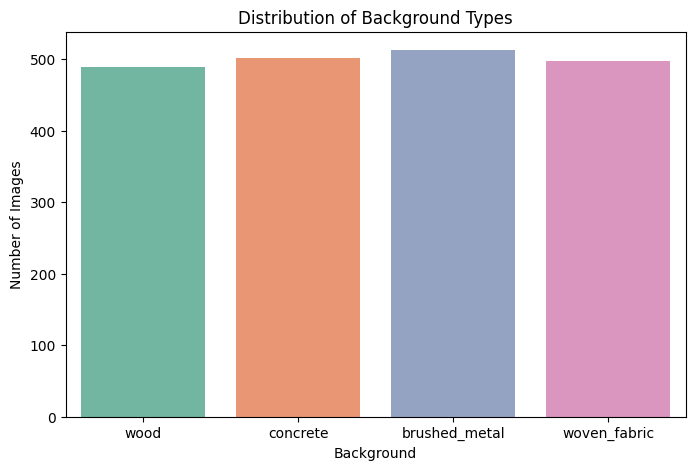

In [9]:
#background distribution 
train_meta = metadata[metadata["split"] == "train"]

plt.figure(figsize=(8,5))

sns.countplot(
    data=train_meta,
    x="background",
    palette="Set2"
)

plt.title("Distribution of Background Types")
plt.xlabel("Background")
plt.ylabel("Number of Images")
plt.show()

• The dataset contains multiple background surfaces such as wood and concrete.

• This variation introduces visual diversity and helps the model generalize better.

• Since the same mechanical objects appear on different backgrounds, the network must learn object-specific features rather than relying on background information.

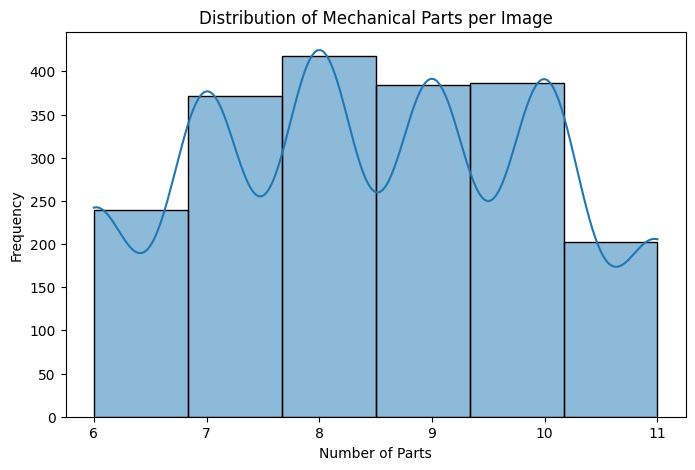

In [10]:
# Distribution of number of parts
plt.figure(figsize=(8,5))

sns.histplot(
    train_meta["n_parts"],
    bins=6,
    kde=True
)

plt.title("Distribution of Mechanical Parts per Image")
plt.xlabel("Number of Parts")
plt.ylabel("Frequency")
plt.show()

• Most images contain between 7 and 10 objects.

• The average number of parts is around 8.

• The relatively small variation in object count suggests that the dataset has a balanced level of scene complexity.

## Load Train and Test Files

In [11]:
train_images = sorted(os.listdir(TRAIN_IMAGE_PATH))
train_masks = sorted(os.listdir(TRAIN_MASK_PATH))
test_images = sorted(os.listdir(TEST_IMAGE_PATH))

print("="*60)
print("TRAIN / TEST DATASET INFORMATION")
print("="*60)

print(f"Training Images : {len(train_images)}")
print(f"Training Masks  : {len(train_masks)}")
print(f"Testing Images  : {len(test_images)}\n")

# verifying the filenames
print(train_images[:5])

print(train_masks[:5])

print(test_images[:5])

# verify image-mask correspondence

assert train_images == train_masks

print("\nAll training images have corresponding masks.")

TRAIN / TEST DATASET INFORMATION
Training Images : 2000
Training Masks  : 2000
Testing Images  : 500

['img_00000.png', 'img_00002.png', 'img_00003.png', 'img_00004.png', 'img_00006.png']
['img_00000.png', 'img_00002.png', 'img_00003.png', 'img_00004.png', 'img_00006.png']
['img_00001.png', 'img_00005.png', 'img_00008.png', 'img_00016.png', 'img_00021.png']

All training images have corresponding masks.


## Image Properties

In [12]:
sample_image = train_images[0]

image = Image.open(os.path.join(TRAIN_IMAGE_PATH, sample_image))

image_array = np.array(image)

print("="*60)
print("SAMPLE TRAINING IMAGE INFORMATION")
print("="*60)

print(f"Filename        : {sample_image}")
print(f"Image Size      : {image.size}")
print(f"Image Mode      : {image.mode}")
print(f"Image Shape     : {image_array.shape}")
print(f"Data Type       : {image_array.dtype}")
print(f"Minimum Pixel   : {image_array.min()}")
print(f"Maximum Pixel   : {image_array.max()}")

SAMPLE TRAINING IMAGE INFORMATION
Filename        : img_00000.png
Image Size      : (384, 384)
Image Mode      : RGB
Image Shape     : (384, 384, 3)
Data Type       : uint8
Minimum Pixel   : 0
Maximum Pixel   : 255


## Mask Properties

In [13]:
sample_mask = train_masks[0]

mask = np.array(Image.open(os.path.join(TRAIN_MASK_PATH, sample_mask)))

print("="*60)
print("SAMPLE MASK INFORMATION")
print("="*60)

print(f"Filename        : {sample_mask}")
print(f"Mask Shape      : {mask.shape}")
print(f"Data Type       : {mask.dtype}")
print(f"Unique Labels   : {np.unique(mask)}")

SAMPLE MASK INFORMATION
Filename        : img_00000.png
Mask Shape      : (384, 384)
Data Type       : uint8
Unique Labels   : [0 1 2 3 4 5 6]


## Display Random Images 

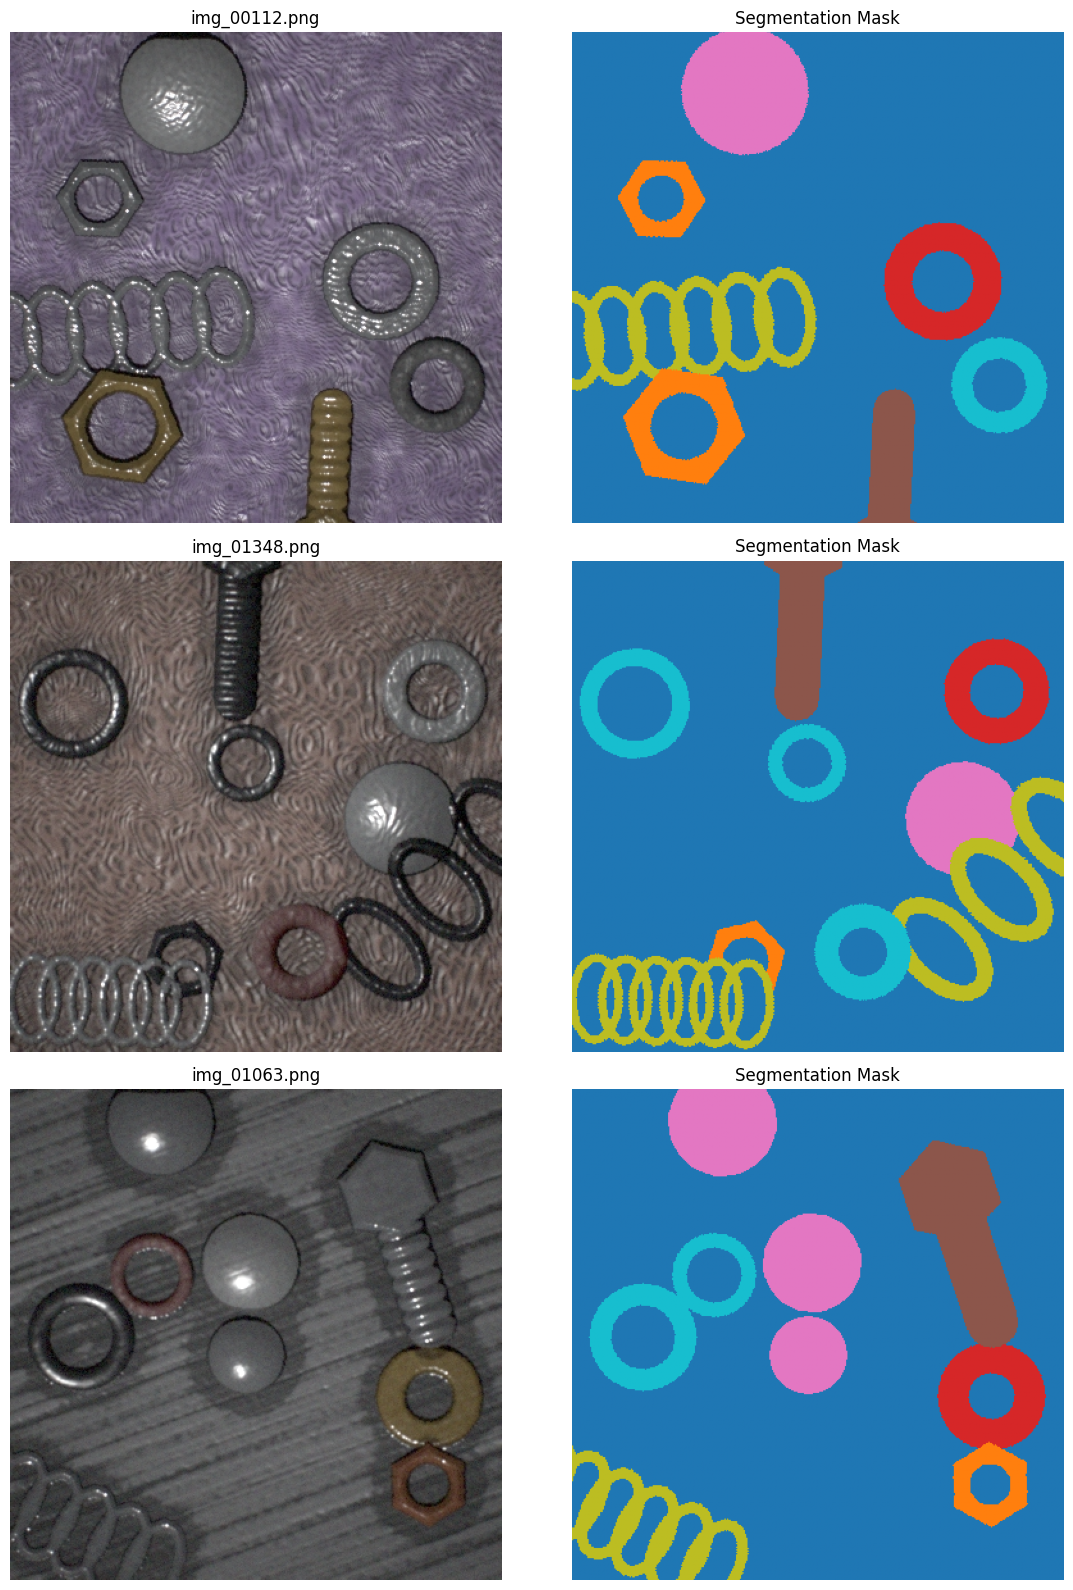

In [14]:
fig, axes = plt.subplots(3,2,figsize=(12,16))

samples = random.sample(train_images,3)

for i,file in enumerate(samples):

    image = np.array(Image.open(os.path.join(TRAIN_IMAGE_PATH,file)))
    mask = np.array(Image.open(os.path.join(TRAIN_MASK_PATH,file)))

    axes[i,0].imshow(image)
    axes[i,0].set_title(file)
    axes[i,0].axis("off")

    axes[i,1].imshow(mask,cmap="tab10")
    axes[i,1].set_title("Segmentation Mask")
    axes[i,1].axis("off")

plt.tight_layout()

## Plotting of important graphs (Pixel Distribution and Foreground Coverage)

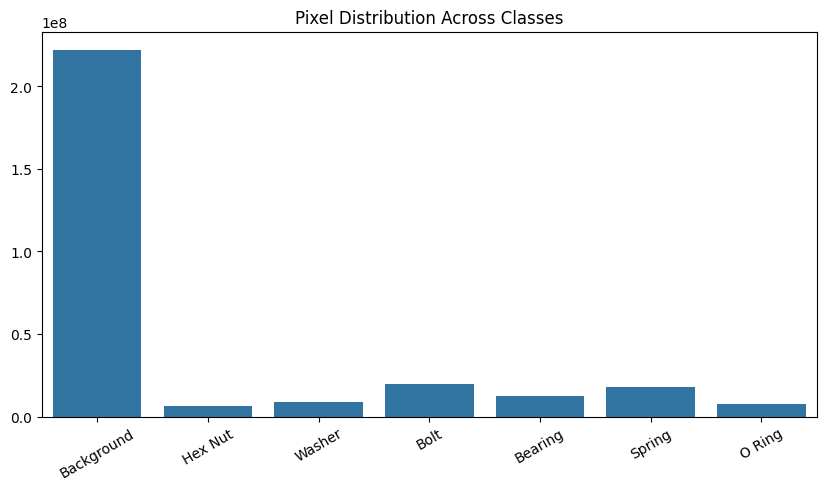

In [15]:
pixel_counts = np.zeros(7)

for file in train_masks:

    mask = np.array(Image.open(os.path.join(TRAIN_MASK_PATH,file)))

    unique, counts = np.unique(mask,return_counts=True)

    for u,c in zip(unique,counts):

        pixel_counts[u]+=c

classes = [
    "Background",
    "Hex Nut",
    "Washer",
    "Bolt",
    "Bearing",
    "Spring",
    "O Ring"
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=classes,
    y=pixel_counts
)

plt.xticks(rotation=30)

plt.title("Pixel Distribution Across Classes")

plt.show()

### Key Observations

- The background class contains significantly more pixels than any foreground class.
- Among the mechanical components, **Bolt** and **Spring** occupy the largest regions, whereas **Hex Nut** and **O Ring** contribute fewer pixels.
- This pixel imbalance may bias the model toward predicting larger classes more accurately than smaller ones.
- To mitigate this issue, we will later experiment with overlap-aware loss functions such as Dice Loss combined with CrossEntropy Loss.

In [16]:
foreground = []
background = []

for file in train_masks:

    mask = np.array(Image.open(os.path.join(TRAIN_MASK_PATH,file)))

    foreground.append((mask>0).mean()*100)

    background.append((mask==0).mean()*100)

coverage_df = pd.DataFrame({
    "Foreground": foreground,
    "Background": background
})

coverage_df.head()

,Foreground,Background
0,20.981852,79.018148
1,23.441569,76.558431
2,23.657227,76.342773
3,19.049072,80.950928
4,27.084690,72.915310


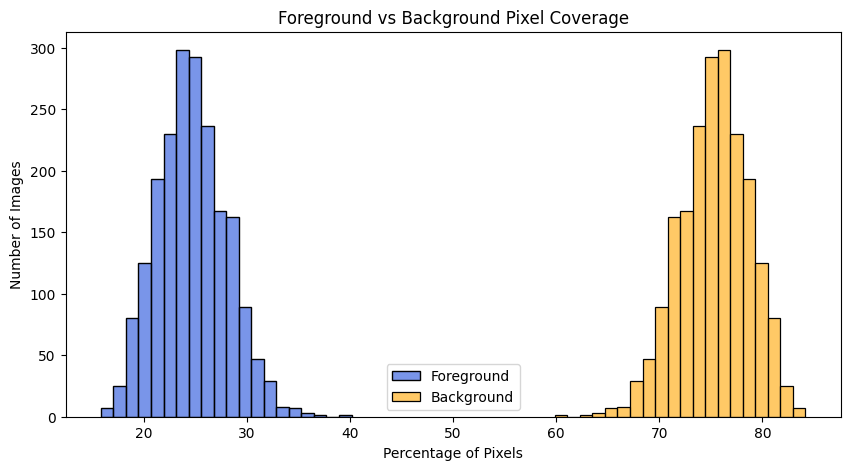

FOREGROUND / BACKGROUND COVERAGE
Average Foreground Coverage : 24.67%
Average Background Coverage : 75.33%
Minimum Foreground Coverage : 15.84%
Maximum Foreground Coverage : 40.14%


In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    foreground,
    bins=20,
    color="royalblue",
    alpha=0.7,
    label="Foreground"
)

sns.histplot(
    background,
    bins=20,
    color="orange",
    alpha=0.6,
    label="Background"
)

plt.title("Foreground vs Background Pixel Coverage")
plt.xlabel("Percentage of Pixels")
plt.ylabel("Number of Images")
plt.legend()

plt.show()

print("=" * 60)
print("FOREGROUND / BACKGROUND COVERAGE")
print("=" * 60)

print(f"Average Foreground Coverage : {np.mean(foreground):.2f}%")
print(f"Average Background Coverage : {np.mean(background):.2f}%")

print(f"Minimum Foreground Coverage : {np.min(foreground):.2f}%")
print(f"Maximum Foreground Coverage : {np.max(foreground):.2f}%")

### Key Observations

- On average, only **24.67%** of each image corresponds to foreground objects.
- Approximately **75.33%** of every image consists of background pixels.
- Foreground coverage varies between **15.84%** and **40.14%**, indicating moderate variation in scene occupancy.
- The dominance of background pixels introduces class imbalance, making overlap-based loss functions such as Dice Loss particularly useful.

,Class,Pixel Percentage
0,Background,75.326550
1,Hex Nut,2.260310
2,Washer,2.965673
3,Bolt,6.621220
4,Bearing,4.170270
5,Spring,6.053608
6,O Ring,2.602369


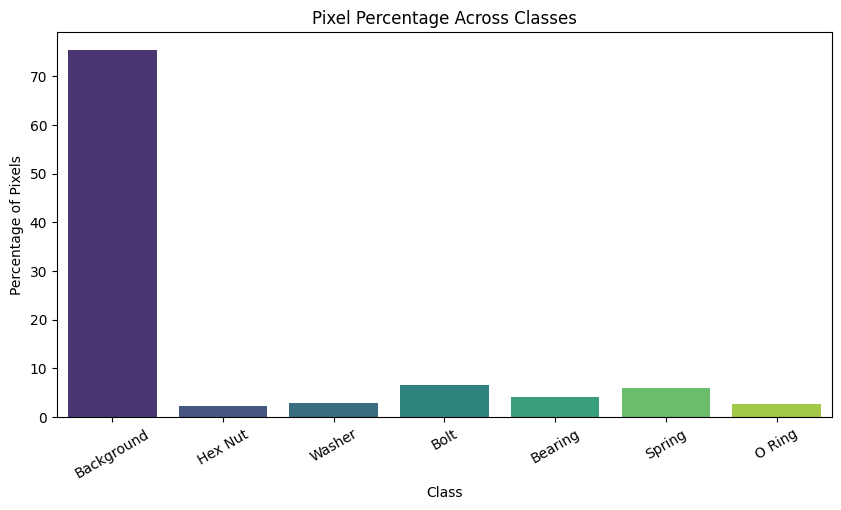

In [18]:
#pixel percentages
pixel_percent = pixel_counts / pixel_counts.sum() * 100

pixel_df = pd.DataFrame({
    "Class": classes,
    "Pixel Percentage": pixel_percent
})

display(pixel_df)

plt.figure(figsize=(10,5))

sns.barplot(
    data=pixel_df,
    x="Class",
    y="Pixel Percentage",
    palette="viridis"
)

plt.xticks(rotation=30)

plt.ylabel("Percentage of Pixels")

plt.title("Pixel Percentage Across Classes")

plt.show()

## Image Properties

Before training a segmentation model, it is important to inspect the raw training images. This helps us understand the image dimensions, color format, pixel value range, and storage type, all of which influence preprocessing and model design.

### Sample_Image Properties

SAMPLE TRAINING IMAGE INFORMATION
Filename          : img_00000.png
Image Size        : (384, 384)
Image Shape       : (384, 384, 3)
Image Mode        : RGB
Data Type         : uint8
Minimum Pixel     : 0
Maximum Pixel     : 255
Mean Pixel Value  : 69.25

DATASET IMAGE STATISTICS
Average Mean Pixel Value : 85.71
Average Std Pixel Value  : 24.28
Minimum Mean            : 53.71
Maximum Mean            : 131.31



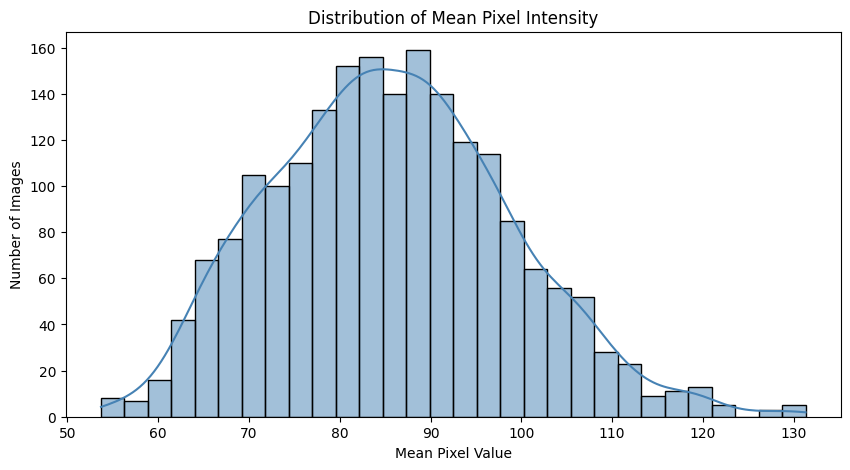

In [19]:
sample_image_name = train_images[0]

sample_image_path = os.path.join(TRAIN_IMAGE_PATH, sample_image_name)

sample_image = Image.open(sample_image_path)
sample_image_array = np.array(sample_image)

print("=" * 60)
print("SAMPLE TRAINING IMAGE INFORMATION")
print("=" * 60)

print(f"Filename          : {sample_image_name}")
print(f"Image Size        : {sample_image.size}")
print(f"Image Shape       : {sample_image_array.shape}")
print(f"Image Mode        : {sample_image.mode}")
print(f"Data Type         : {sample_image_array.dtype}")
print(f"Minimum Pixel     : {sample_image_array.min()}")
print(f"Maximum Pixel     : {sample_image_array.max()}")
print(f"Mean Pixel Value  : {sample_image_array.mean():.2f}\n")

image_means = []
image_stds = []

for file in train_images:
    image = np.array(Image.open(os.path.join(TRAIN_IMAGE_PATH, file)))

    image_means.append(image.mean())
    image_stds.append(image.std())

print("=" * 60)
print("DATASET IMAGE STATISTICS")
print("=" * 60)

print(f"Average Mean Pixel Value : {np.mean(image_means):.2f}")
print(f"Average Std Pixel Value  : {np.mean(image_stds):.2f}")

print(f"Minimum Mean            : {np.min(image_means):.2f}")
print(f"Maximum Mean            : {np.max(image_means):.2f}\n")

plt.figure(figsize=(10,5))

sns.histplot(image_means, bins=30, color="steelblue", kde=True)

plt.title("Distribution of Mean Pixel Intensity")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Number of Images")

plt.show()

### Sample Mask properties 
Unlike RGB images, segmentation masks store the class label for every pixel. Each pixel contains an integer representing one of the predefined classes rather than a color value.

In [20]:
sample_mask_name = train_masks[0]

sample_mask_path = os.path.join(TRAIN_MASK_PATH, sample_mask_name)

sample_mask = np.array(Image.open(sample_mask_path))

print("=" * 60)
print("SAMPLE SEGMENTATION MASK INFORMATION")
print("=" * 60)

print(f"Filename          : {sample_mask_name}")
print(f"Mask Shape        : {sample_mask.shape}")
print(f"Data Type         : {sample_mask.dtype}")
print(f"Unique Labels     : {np.unique(sample_mask)}")

SAMPLE SEGMENTATION MASK INFORMATION
Filename          : img_00000.png
Mask Shape        : (384, 384)
Data Type         : uint8
Unique Labels     : [0 1 2 3 4 5 6]


### Label Mapping 
The segmentation masks use integer values to represent different object categories. The following mapping will be used throughout the notebook.

In [21]:
label_mapping = {
    0: "Background",
    1: "Hex Nut",
    2: "Washer",
    3: "Bolt",
    4: "Ball Bearing",
    5: "Spring",
    6: "O Ring"
}

display(
    pd.DataFrame(
        label_mapping.items(),
        columns=["Pixel Value", "Class Name"]
    )
)

,Pixel Value,Class Name
0,0,Background
1,1,Hex Nut
2,2,Washer
3,3,Bolt
4,4,Ball Bearing
5,5,Spring
6,6,O Ring


### Visualize Random Images

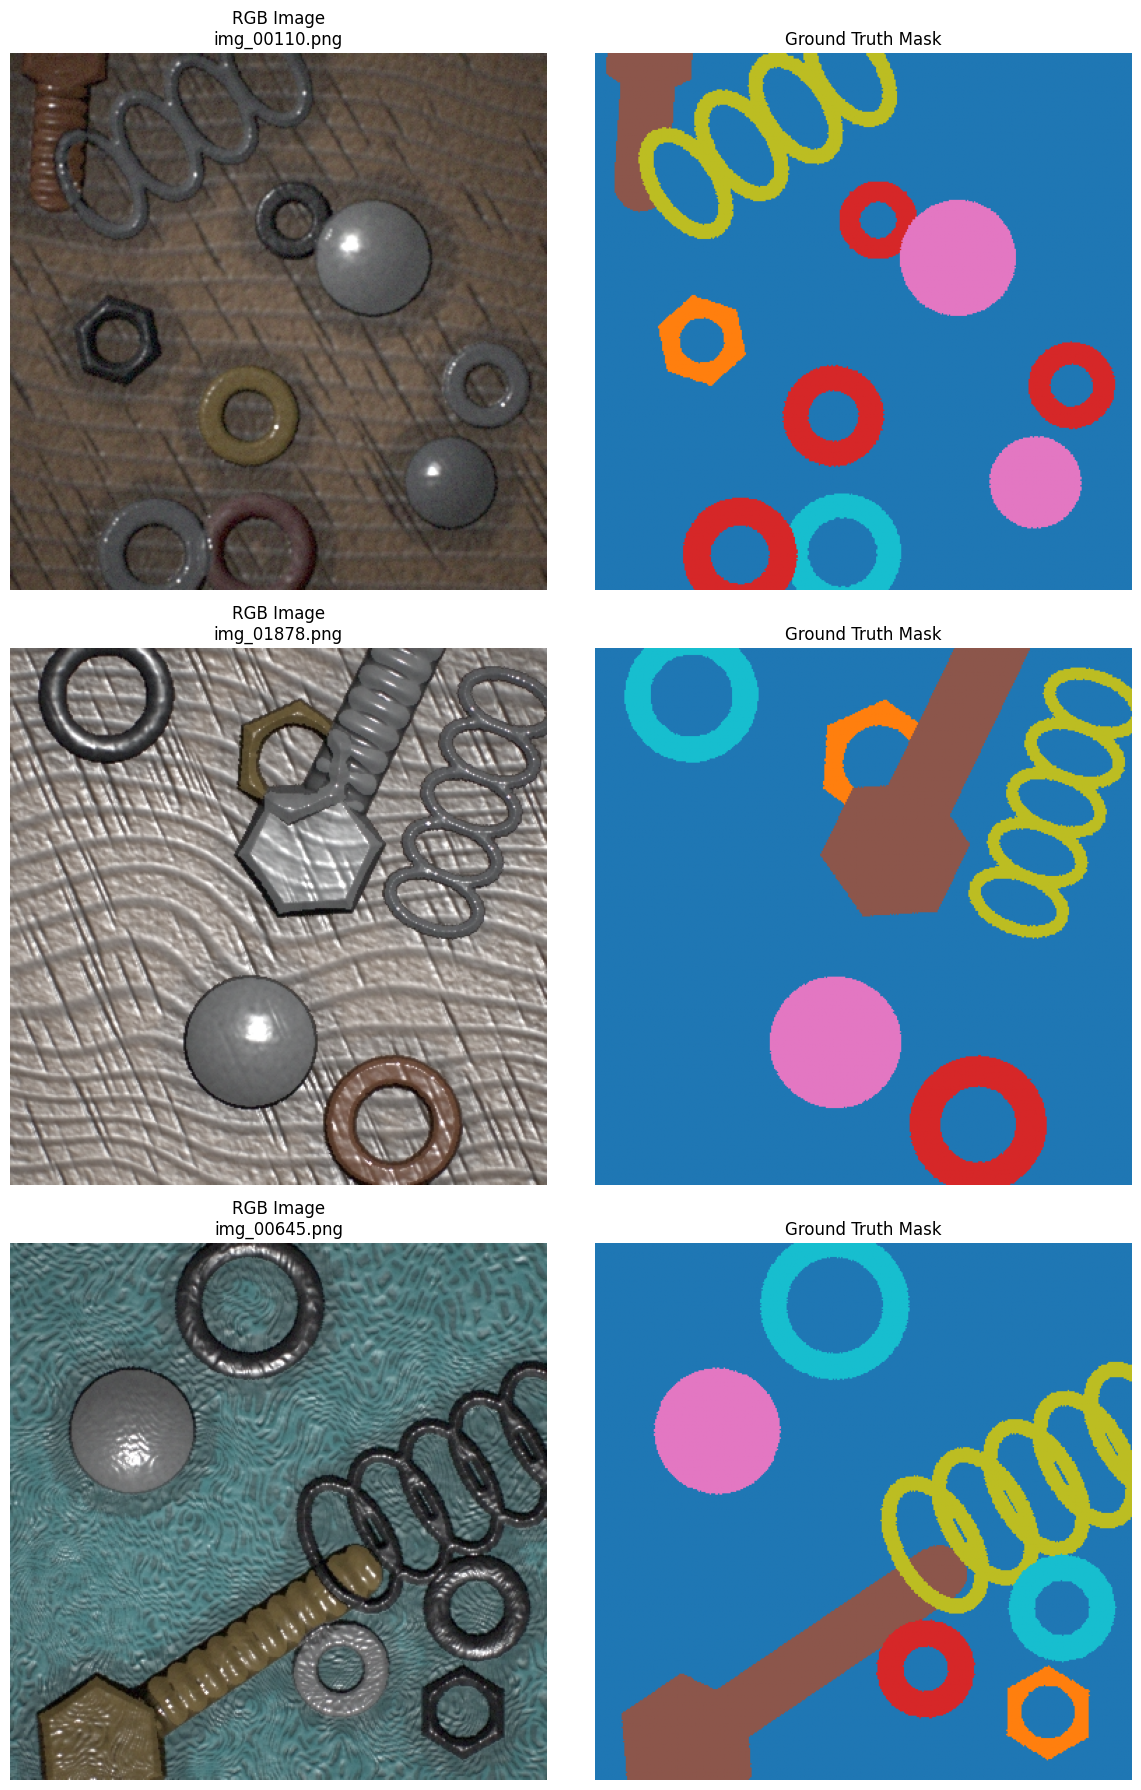

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))

random_samples = random.sample(train_images, 3)

for i, filename in enumerate(random_samples):

    image = np.array(Image.open(os.path.join(TRAIN_IMAGE_PATH, filename)))
    mask = np.array(Image.open(os.path.join(TRAIN_MASK_PATH, filename)))

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f"RGB Image\n{filename}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="tab10")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

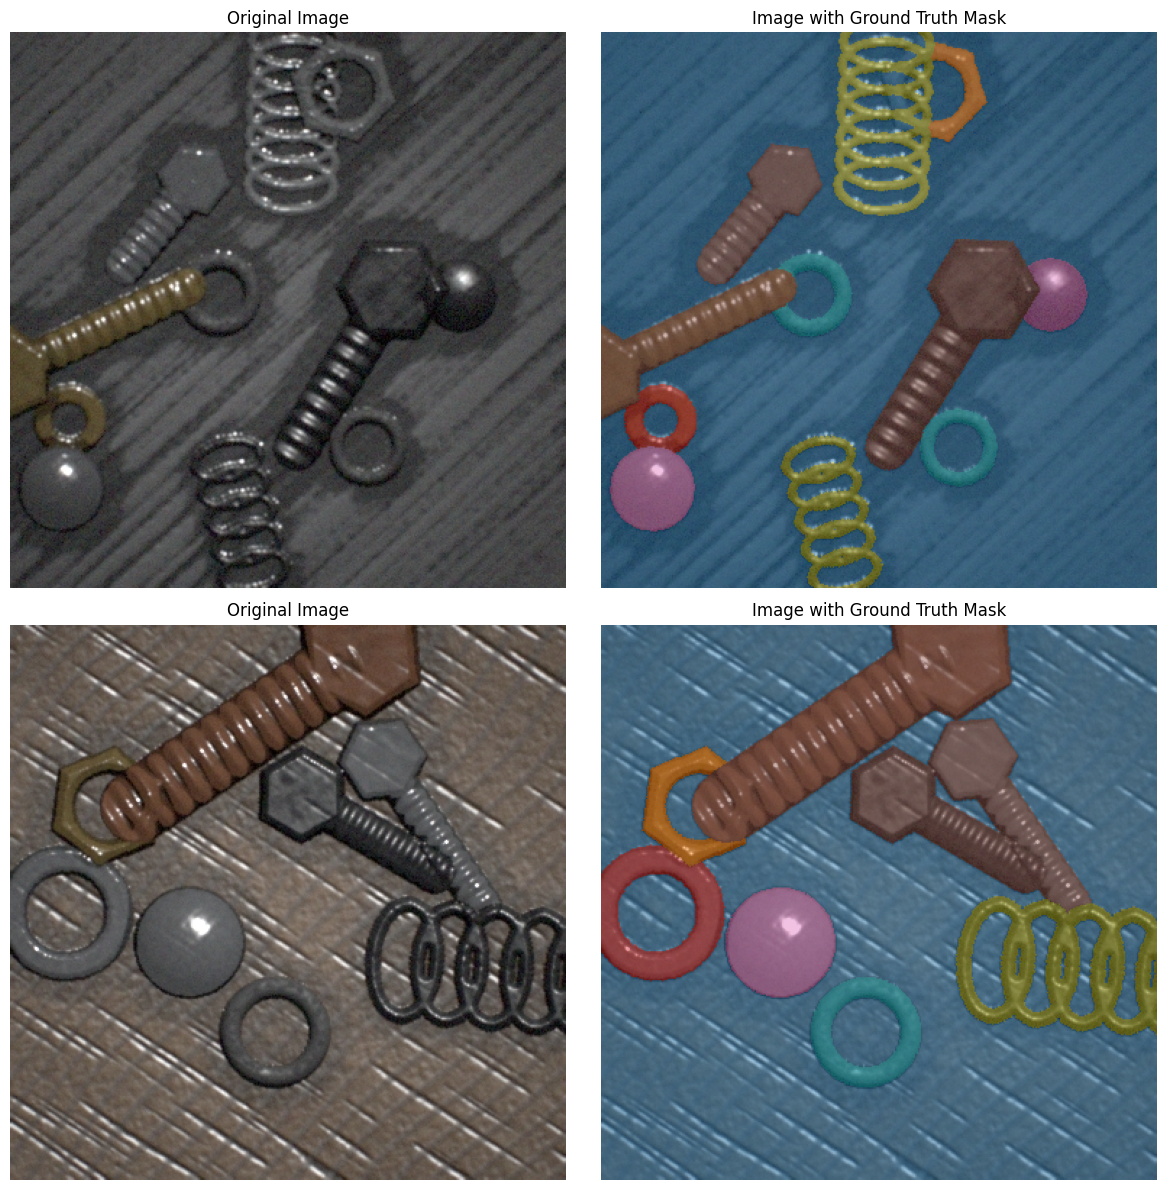

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

random_samples = random.sample(train_images, 2)

for i, filename in enumerate(random_samples):

    image = np.array(Image.open(os.path.join(TRAIN_IMAGE_PATH, filename)))
    mask = np.array(Image.open(os.path.join(TRAIN_MASK_PATH, filename)))

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(image)
    axes[i, 1].imshow(mask, cmap="tab10", alpha=0.45)
    axes[i, 1].set_title("Image with Ground Truth Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Dataset Health 
### Missing values in metadata

In [24]:
print("=" * 60)
print("MISSING VALUES IN METADATA")
print("=" * 60)

missing_values = metadata.isnull().sum()

display(
    pd.DataFrame({
        "Column": missing_values.index,
        "Missing Values": missing_values.values
    })
)

MISSING VALUES IN METADATA


,Column,Missing Values
0,id,0
1,split,0
2,background,500
3,n_parts,500
4,classes_present,500


### Duplicate Records

In [25]:
print("=" * 60)
print("DUPLICATE RECORD CHECK")
print("=" * 60)

duplicate_rows = metadata.duplicated().sum()
duplicate_ids = metadata["id"].duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")
print(f"Duplicate Image IDs : {duplicate_ids}")

DUPLICATE RECORD CHECK
Duplicate Rows : 0
Duplicate Image IDs : 0


### Verify Image–Mask Correspondence

In [26]:
missing_masks = sorted(set(train_images) - set(train_masks))
extra_masks = sorted(set(train_masks) - set(train_images))

print("=" * 60)
print("IMAGE - MASK CORRESPONDENCE")
print("=" * 60)

print(f"Missing Masks : {len(missing_masks)}")
print(f"Extra Masks   : {len(extra_masks)}")
assert len(missing_masks) == 0
assert len(extra_masks) == 0

print("Every training image has exactly one corresponding mask.")


IMAGE - MASK CORRESPONDENCE
Missing Masks : 0
Extra Masks   : 0
Every training image has exactly one corresponding mask.


### Corrupted Image Check

In [27]:
corrupted_images = []

for file in train_images:

    try:
        Image.open(os.path.join(TRAIN_IMAGE_PATH, file)).verify()

    except Exception:
        corrupted_images.append(file)

print("=" * 60)
print("CORRUPTED IMAGE CHECK")
print("=" * 60)

print(f"Corrupted Images : {len(corrupted_images)}")

if len(corrupted_images) == 0:
    print("All training images loaded successfully.")

CORRUPTED IMAGE CHECK
Corrupted Images : 0
All training images loaded successfully.


## RLE Verification

RLE VERIFICATION
Encoding Successful : True
Decoded Shape       : (384, 384)

RLE Encode → Decode Verification Passed Successfully.


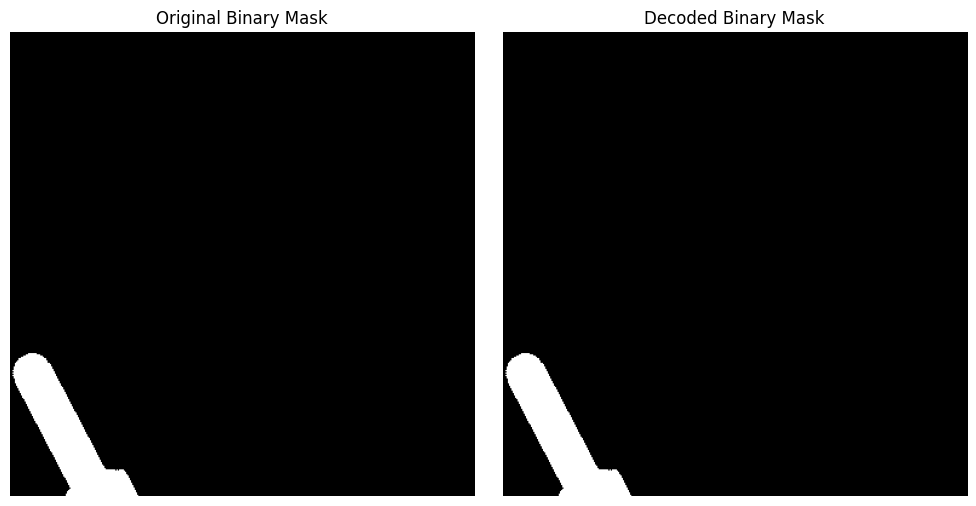

In [28]:
def rle_encode(mask):
    px = np.asarray(mask, np.uint8).T.flatten()
    px = np.concatenate([[0], px, [0]])
    runs = np.where(px[1:] != px[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(int(x)) for x in runs)

def rle_decode(rle, size=384):
    m = np.zeros(size * size, np.uint8)
    if not isinstance(rle, str) or not rle.strip():
        return m.reshape(size, size, order="F")
    a = np.asarray(rle.split(), np.int64)
    for s, l in zip(a[0::2], a[1::2]):
        m[s - 1:s - 1 + l] = 1
    return m.reshape(size, size, order="F")

sample_mask = np.array(
    Image.open(os.path.join(TRAIN_MASK_PATH, train_masks[0]))
)

# Example: Bolt class (class id = 3)
binary_mask = (sample_mask == 3).astype(np.uint8)

encoded = rle_encode(binary_mask)
decoded = rle_decode(encoded)

print("=" * 60)
print("RLE VERIFICATION")
print("=" * 60)

print("Encoding Successful :", isinstance(encoded, str))
print("Decoded Shape       :", decoded.shape)

assert np.array_equal(binary_mask, decoded)

print("\nRLE Encode → Decode Verification Passed Successfully.")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(binary_mask, cmap="gray")
axes[0].set_title("Original Binary Mask")
axes[0].axis("off")

axes[1].imshow(decoded, cmap="gray")
axes[1].set_title("Decoded Binary Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Phase 2 -- Data Preprocessing 

## Reproducibility

In [29]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random Seed Set : {SEED}")

Random Seed Set : 42


## Train_validation 

In [30]:
train_files, valid_files = train_test_split(
    train_images,
    test_size=0.15,
    random_state=SEED,
    shuffle=True
)

print("=" * 60)
print("TRAIN - VALIDATION SPLIT")
print("=" * 60)

print(f"Training Images   : {len(train_files)}")
print(f"Validation Images : {len(valid_files)}")

TRAIN - VALIDATION SPLIT
Training Images   : 1700
Validation Images : 300


>Why 85% / 15%?

An 85–15 split provides sufficient data for training while reserving an independent validation set for monitoring model performance and detecting overfitting during training.

## Compute Dataset Mean & Standard Deviation
Before defining the preprocessing pipeline, we compute the channel-wise mean and standard deviation of the training images. These statistics are later used for image normalization.

Using dataset-specific normalization ensures that the preprocessing is tailored to the characteristics of the provided dataset rather than relying on external datasets.

In [31]:
def compute_mean_std(image_files, image_dir):
    """
    Computes channel-wise mean and standard deviation
    for the training dataset.
    """

    channel_sum = np.zeros(3)
    channel_squared_sum = np.zeros(3)
    total_pixels = 0

    for file in image_files:

        image = np.array(
            Image.open(os.path.join(image_dir, file))
        ).astype(np.float32) / 255.0

        channel_sum += image.sum(axis=(0, 1))
        channel_squared_sum += (image ** 2).sum(axis=(0, 1))

        total_pixels += image.shape[0] * image.shape[1]

    mean = channel_sum / total_pixels
    std = np.sqrt(channel_squared_sum / total_pixels - mean ** 2)

    return mean, std

dataset_mean, dataset_std = compute_mean_std(
    train_files,
    TRAIN_IMAGE_PATH
)

print("=" * 60)
print("DATASET NORMALIZATION STATISTICS")
print("=" * 60)

print(f"Mean : {dataset_mean}")
print(f"Std  : {dataset_std}")

DATASET NORMALIZATION STATISTICS
Mean : [0.34640554 0.33531815 0.32624377]
Std  : [0.11061098 0.10952163 0.11083191]


## Data Augmentation

In [32]:
train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.Rotate(
        limit=20,
        interpolation=cv2.INTER_LINEAR,
        mask_interpolation=cv2.INTER_NEAREST,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.Normalize(
        mean=dataset_mean.tolist(),
        std=dataset_std.tolist()
    ),

    ToTensorV2()

])
valid_transform = A.Compose([

    A.Normalize(
        mean=dataset_mean.tolist(),
        std=dataset_std.tolist()
    ),

    ToTensorV2()

])

## Dataset Class

PyTorch uses the `Dataset` class to efficiently load training samples during model training.

The custom dataset will perform the following operations for every sample:

- Read the RGB image.
- Read the corresponding segmentation mask.
- Apply preprocessing and augmentation.
- Convert both the image and mask into PyTorch tensors.

In [33]:
class MechanicalPartsDataset(Dataset):

    def __init__(
        self,
        image_files,
        image_dir,
        mask_dir=None,
        transform=None
    ):
        self.image_files = image_files
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):

        image_name = self.image_files[index]
    
        image_path = os.path.join(
            self.image_dir,
            image_name
        )
    
        image = np.array(
            Image.open(image_path).convert("RGB")
        )
    
        if self.mask_dir is not None:
    
            mask_path = os.path.join(
                self.mask_dir,
                image_name
            )
    
            mask = np.array(
                Image.open(mask_path)
            )
    
            if self.transform:
    
                augmented = self.transform(
                    image=image,
                    mask=mask
                )
    
                image = augmented["image"]
                mask = augmented["mask"].long()
    
            return image, mask
    
        else:
    
            if self.transform:
    
                augmented = self.transform(
                    image=image
                )
    
                image = augmented["image"]
    
            return image

train_dataset = MechanicalPartsDataset(
    image_files=train_files,
    image_dir=TRAIN_IMAGE_PATH,
    mask_dir=TRAIN_MASK_PATH,
    transform=train_transform
)

print("Dataset Length :", len(train_dataset))

image, mask = train_dataset[0]

print("=" * 60)
print("DATASET SAMPLE")
print("=" * 60)

print(f"Image Shape : {image.shape}")
print(f"Mask Shape  : {mask.shape}")

print(f"Image dtype : {image.dtype}")
print(f"Mask dtype  : {mask.dtype}")

print(f"Image Min   : {image.min():.3f}")
print(f"Image Max   : {image.max():.3f}")

print(f"Mask Labels : {torch.unique(mask)}")


Dataset Length : 1700
DATASET SAMPLE
Image Shape : torch.Size([3, 384, 384])
Mask Shape  : torch.Size([384, 384])
Image dtype : torch.float32
Mask dtype  : torch.int64
Image Min   : -2.742
Image Max   : 5.690
Mask Labels : tensor([0, 1, 2, 3, 4, 5, 6])


## Dataset Objects

In [34]:
train_dataset = MechanicalPartsDataset(
    image_files=train_files,
    image_dir=TRAIN_IMAGE_PATH,
    mask_dir=TRAIN_MASK_PATH,
    transform=train_transform
)

valid_dataset = MechanicalPartsDataset(
    image_files=valid_files,
    image_dir=TRAIN_IMAGE_PATH,
    mask_dir=TRAIN_MASK_PATH,
    transform=valid_transform
)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Training Dataset :", len(train_dataset))
print("Validation Dataset :", len(valid_dataset))

DATASET INFORMATION
Training Dataset : 1700
Validation Dataset : 300


## DataLoaders

In [35]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("=" * 60)
print("DATALOADER INFORMATION")
print("=" * 60)

print(f"Batch Size          : {BATCH_SIZE}")
print(f"Training Batches    : {len(train_loader)}")
print(f"Validation Batches  : {len(valid_loader)}")

DATALOADER INFORMATION
Batch Size          : 8
Training Batches    : 213
Validation Batches  : 38


### Verifying the Dataloader

In [36]:
images, masks = next(iter(train_loader))

print("=" * 60)
print("TRAINING BATCH")
print("=" * 60)

print(f"Images Shape : {images.shape}")
print(f"Masks Shape  : {masks.shape}")

print(f"Images dtype : {images.dtype}")
print(f"Masks dtype  : {masks.dtype}")

print(f"Unique Labels: {torch.unique(masks)}")

TRAINING BATCH
Images Shape : torch.Size([8, 3, 384, 384])
Masks Shape  : torch.Size([8, 384, 384])
Images dtype : torch.float32
Masks dtype  : torch.int64
Unique Labels: tensor([0, 1, 2, 3, 4, 5, 6])


## Phase 2 Summary

In this phase, a complete preprocessing pipeline was constructed for semantic segmentation.

The following tasks were completed:

- Established reproducibility by fixing the random seed.
- Created an 85–15 train–validation split.
- Computed dataset-specific normalization statistics.
- Defined augmentation pipelines for both training and validation.
- Implemented a custom PyTorch Dataset for loading images and masks.
- Built efficient DataLoaders for mini-batch training.
- Verified tensor shapes, data types, class labels, and batch generation.
- Visualized preprocessed training samples to confirm the correctness of the pipeline.

The dataset is now fully prepared for training a deep learning segmentation model.

# Phase 3 -- Model Development

## Why U-Net??
U-Net is one of the most widely used architectures for semantic segmentation because it combines two important properties:

- The encoder extracts high-level semantic information from the input image.
- The decoder gradually reconstructs the segmentation mask while recovering spatial information.

A key feature of U-Net is the use of skip connections, which transfer fine-grained spatial details from the encoder to the decoder. This helps preserve object boundaries and improves segmentation accuracy.

For this competition, a custom U-Net will be implemented from scratch without using any pretrained encoders.

In [37]:
print("=" * 60)
print("DEVICE INFORMATION")
print("=" * 60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU Name : {torch.cuda.get_device_name(0)}")

DEVICE INFORMATION
Device : cuda
GPU Name : Tesla T4


## Double Convolutional Block
The Double Convolution block is the fundamental building block of the U-Net architecture.

Each block consists of:

- Convolution (3×3)
- Batch Normalization
- ReLU Activation
- Convolution (3×3)
- Batch Normalization
- ReLU Activation

Using two consecutive convolutional layers allows the network to learn richer spatial features while preserving the image resolution through appropriate padding.

In [38]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.double_conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.double_conv(x)

double_conv = DoubleConv(
    in_channels=3,
    out_channels=64
)

double_conv = double_conv.to(device)

sample = torch.randn(
    1,
    3,
    384,
    384
).to(device)

output = double_conv(sample)

print("=" * 60)
print("DOUBLE CONVOLUTION BLOCK")
print("=" * 60)

print(f"Input Shape  : {sample.shape}")
print(f"Output Shape : {output.shape}")

DOUBLE CONVOLUTION BLOCK
Input Shape  : torch.Size([1, 3, 384, 384])
Output Shape : torch.Size([1, 64, 384, 384])


## Encoder Block
The encoder gradually extracts higher-level semantic information while reducing the spatial resolution of the feature maps.

Each encoder block consists of:

- Double Convolution
- Max Pooling

The feature map before pooling is preserved for the corresponding skip connection in the decoder.

In [39]:
class EncoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

    def forward(self, x):

        features = self.conv(x)

        pooled = self.pool(features)

        return features, pooled

encoder = EncoderBlock(
    3,
    64
).to(device)

features, pooled = encoder(sample)

print("=" * 60)
print("ENCODER BLOCK")
print("=" * 60)

print(f"Features : {features.shape}")
print(f"Pooled   : {pooled.shape}")

ENCODER BLOCK
Features : torch.Size([1, 64, 384, 384])
Pooled   : torch.Size([1, 64, 192, 192])


## Decoder Block

The decoder gradually reconstructs the segmentation mask by increasing the spatial resolution of the feature maps.

Each decoder block consists of:

- Transposed Convolution for upsampling.
- Skip connection from the encoder.
- Double Convolution for feature refinement.

The skip connections help preserve fine spatial information that may otherwise be lost during downsampling.

In [40]:
class DecoderBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels * 2,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat([skip, x], dim=1)

        x = self.conv(x)

        return x

decoder = DecoderBlock(
    in_channels=128,
    out_channels=64
).to(device)

decoder_input = torch.randn(
    1,
    128,
    192,
    192
).to(device)

skip_connection = torch.randn(
    1,
    64,
    384,
    384
).to(device)

decoder_output = decoder(
    decoder_input,
    skip_connection
)

print("=" * 60)
print("DECODER BLOCK")
print("=" * 60)

print(f"Input Shape      : {decoder_input.shape}")
print(f"Skip Shape       : {skip_connection.shape}")
print(f"Output Shape     : {decoder_output.shape}")

DECODER BLOCK
Input Shape      : torch.Size([1, 128, 192, 192])
Skip Shape       : torch.Size([1, 64, 384, 384])
Output Shape     : torch.Size([1, 64, 384, 384])


## U-Net
The complete U-Net architecture is constructed by combining the previously defined encoder and decoder blocks.

The encoder progressively extracts higher-level semantic features while reducing spatial resolution. The bottleneck captures the deepest feature representation. The decoder then reconstructs the segmentation map using transposed convolutions and skip connections from the encoder.

Finally, a 1×1 convolution projects the output features into seven segmentation classes (background + six mechanical components).

In [41]:
class UNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=7):

        super().__init__()


        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        self.bottleneck = DoubleConv(512, 1024)
        self.dropout = nn.Dropout2d(p=0.30)
        
        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512, 256)
        self.dec2 = DecoderBlock(256, 128)
        self.dec1 = DecoderBlock(128, 64)

        self.final_conv = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )
        

    def forward(self, x):

        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)

        x = self.bottleneck(x)
        x = self.dropout(x)

        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        return self.final_conv(x)

model = UNet().to(device)

sample = torch.randn(
    1,
    3,
    384,
    384
).to(device)

output = model(sample)

print("=" * 60)
print("U-NET MODEL")
print("=" * 60)

print(f"Input Shape  : {sample.shape}")
print(f"Output Shape : {output.shape}")

U-NET MODEL
Input Shape  : torch.Size([1, 3, 384, 384])
Output Shape : torch.Size([1, 7, 384, 384])


## Explicit Kaiming Initialization
### Weight Initialization

To ensure that the network is trained entirely from scratch, all convolutional layers are initialized using Kaiming (He) initialization. Batch Normalization layers are initialized with unit scaling and zero bias.

In [42]:
def initialize_weights(model):

    for module in model.modules():

        if isinstance(module, nn.Conv2d):

            nn.init.kaiming_normal_(
                module.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

            if module.bias is not None:
                nn.init.constant_(module.bias, 0)

        elif isinstance(module, nn.ConvTranspose2d):

            nn.init.kaiming_normal_(
                module.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

            if module.bias is not None:
                nn.init.constant_(module.bias, 0)

        elif isinstance(module, nn.BatchNorm2d):

            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)

initialize_weights(model)

print("Model weights initialized successfully.")

Model weights initialized successfully.


# Phase 4 -- Training Configuaration

## Dice Metric

The competition uses the Dice coefficient as its official evaluation metric. Therefore, before defining the loss function, we first implement the Dice metric to evaluate the overlap between predicted segmentation masks and the corresponding ground truth masks.

The Dice score ranges between:

- **0** → No overlap
- **1** → Perfect overlap

Monitoring the Dice score during validation provides a direct indication of how well the model is expected to perform on the competition leaderboard.

In [43]:
def dice_score(prediction, target, num_classes=7, smooth=1e-6):
    """
    Compute the mean Dice score across all classes.
    """

    prediction = torch.argmax(prediction, dim=1)

    dice_scores = []

    for class_id in range(num_classes):

        pred_mask = (prediction == class_id).float()
        true_mask = (target == class_id).float()

        intersection = (pred_mask * true_mask).sum()

        union = pred_mask.sum() + true_mask.sum()

        if union == 0:
            dice = torch.tensor(
                1.0,
                device=prediction.device
            )
        else:
            dice = (2.0 * intersection + smooth) / (union + smooth)

        dice_scores.append(dice)

    return torch.mean(torch.stack(dice_scores))

dummy_prediction = torch.randn(
    2,
    7,
    384,
    384
).to(device)

dummy_target = torch.randint(
    0,
    7,
    (2, 384, 384)
).to(device)

score = dice_score(
    dummy_prediction,
    dummy_target
)

print("=" * 60)
print("DICE METRIC")
print("=" * 60)

print(f"Dice Score : {score:.4f}")

DICE METRIC
Dice Score : 0.1433


## Dice Loss

Although the Dice coefficient is an evaluation metric, it can also be transformed into a differentiable loss function.

Dice Loss is defined as:

**Dice Loss = 1 − Dice Score**

Minimizing this loss encourages greater overlap between the predicted segmentation masks and the ground truth masks.

In [44]:
class DiceLoss(nn.Module):

    def __init__(self, num_classes=7, smooth=1e-6):
        super().__init__()

        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, prediction, target):

        prediction = torch.softmax(prediction, dim=1)

        target_one_hot = F.one_hot(
            target,
            num_classes=self.num_classes
        )

        target_one_hot = target_one_hot.permute(
            0, 3, 1, 2
        ).float()

        intersection = (prediction * target_one_hot).sum(dim=(2, 3))

        union = prediction.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))

        dice = (2.0 * intersection + self.smooth) / (
            union + self.smooth
        )

        return 1.0 - dice.mean()

criterion = DiceLoss().to(device)

dummy_prediction = torch.randn(
    2,
    7,
    384,
    384
).to(device)

dummy_target = torch.randint(
    0,
    7,
    (2, 384, 384)
).to(device)

loss = criterion(
    dummy_prediction,
    dummy_target
)

print("=" * 60)
print("DICE LOSS")
print("=" * 60)

print(f"Loss : {loss:.4f}")

DICE LOSS
Loss : 0.8572


## Combined Loss

The model is trained using a combination of Cross Entropy Loss and Dice Loss.

Cross Entropy Loss provides stable pixel-wise supervision, while Dice Loss directly optimizes the overlap between the predicted segmentation masks and the ground truth masks.

The total loss is defined as:

**Total Loss = Cross Entropy Loss + Dice Loss**

In [45]:
class CombinedLoss(nn.Module):

    def __init__(self, num_classes=7):

        super().__init__()

        self.cross_entropy = nn.CrossEntropyLoss()

        self.dice = DiceLoss(num_classes=num_classes)

    def forward(self, prediction, target):

        ce_loss = self.cross_entropy(
            prediction,
            target
        )

        dice_loss = self.dice(
            prediction,
            target
        )

        total_loss = ce_loss + dice_loss

        return total_loss

criterion = CombinedLoss().to(device)

dummy_prediction = torch.randn(
    2,
    7,
    384,
    384
).to(device)

dummy_target = torch.randint(
    0,
    7,
    (2, 384, 384)
).to(device)

loss = criterion(
    dummy_prediction,
    dummy_target
)

print("=" * 60)
print("COMBINED LOSS")
print("=" * 60)

print(f"Loss : {loss:.4f}")

COMBINED LOSS
Loss : 3.2027


## Optimizer

The U-Net model is optimized using the AdamW optimizer.

AdamW combines adaptive learning rates with decoupled weight decay, helping the network converge efficiently while reducing overfitting.


In [46]:
LEARNING_RATE = 1e-3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

print("=" * 60)
print("OPTIMIZER")
print("=" * 60)

print(optimizer)

OPTIMIZER
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## Learning Rate Scheduler
Instead of keeping the learning rate fixed, a scheduler will be there to  reduce it automatically when validation performance stops improving.

We will use ReduceLROnPlateau

In [47]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",     
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Learning Rate Scheduler Created Successfully.")

Learning Rate Scheduler Created Successfully.


## Mixed Precision Training (AMP)

The model is trained using Automatic Mixed Precision (AMP) to improve computational efficiency on NVIDIA GPUs.

AMP performs many operations using half-precision floating point arithmetic while maintaining numerical stability through gradient scaling.

Benefits include:

- Faster training.
- Reduced GPU memory consumption.
- Stable optimization through dynamic gradient scaling.

In [48]:
scaler = GradScaler("cuda")

print("=" * 60)
print("AUTOMATIC MIXED PRECISION")
print("=" * 60)
print("GradScaler initialized successfully.")

AUTOMATIC MIXED PRECISION
GradScaler initialized successfully.


## Training Function
For every mini-batch, it:

- Moves the data to the selected device.
- Performs the forward pass.
- Computes the combined loss.
- Uses Automatic Mixed Precision for efficient computation.
- Updates the model parameters.
- Computes the average training loss.

In [49]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    for images, masks in dataloader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

    return running_loss / len(dataloader)

## Validation Function
The validation function evaluates the model without updating its parameters.

During validation, the following metrics are computed:

- Average validation loss.
- Mean Dice score.

The Dice score is used as the primary metric for model selection because it matches the competition evaluation criterion.

In [50]:
def validate_one_epoch(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    running_dice = 0.0

    with torch.no_grad():

        for images, masks in dataloader:

            images = images.to(device)
            masks = masks.to(device)

            with autocast(device_type="cuda"):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    masks
                )

            running_loss += loss.item()

            running_dice += dice_score(
                outputs,
                masks
            ).item()

    return (
        running_loss / len(dataloader),
        running_dice / len(dataloader)
    )

## Early Stopping 
To reduce overfitting and unnecessary computation, an Early Stopping strategy is used.

In [51]:
class EarlyStopping:

    def __init__(self, patience=8):

        self.patience = patience
        self.best_score = 0.0
        self.counter = 0
        self.early_stop = False

    def __call__(self, score):

        if score > self.best_score:

            self.best_score = score
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

## Training Configuaration

In [52]:
NUM_EPOCHS = 30

LEARNING_RATE = 1e-3

MODEL_PATH = "best_unet_model.pth"

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print(f"Epochs        : {NUM_EPOCHS}")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Batch Size    : {BATCH_SIZE}")

TRAINING CONFIGURATION
Epochs        : 30
Learning Rate : 0.001
Batch Size    : 8


## Complete Training Loop

In [53]:
train_losses = []
valid_losses = []
valid_dices = []

best_dice = 0.0

early_stopping = EarlyStopping(patience=8)

for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler,
        device
    )

    valid_loss, valid_dice = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    scheduler.step(valid_dice)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_dices.append(valid_dice)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | "
        f"Dice: {valid_dice:.4f}"
    )

    if valid_dice > best_dice:

        best_dice = valid_dice

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print("Best model saved.")

    early_stopping(valid_dice)

    if early_stopping.early_stop:

        print("Early stopping triggered.")
        break

Epoch [1/30] | Train Loss: 1.3402 | Valid Loss: 1.0371 | Dice: 0.5497
Best model saved.
Epoch [2/30] | Train Loss: 0.9040 | Valid Loss: 0.7856 | Dice: 0.6352
Best model saved.
Epoch [3/30] | Train Loss: 0.6032 | Valid Loss: 0.4670 | Dice: 0.8101
Best model saved.
Epoch [4/30] | Train Loss: 0.3823 | Valid Loss: 0.3144 | Dice: 0.8737
Best model saved.
Epoch [5/30] | Train Loss: 0.2461 | Valid Loss: 0.1869 | Dice: 0.9280
Best model saved.
Epoch [6/30] | Train Loss: 0.1836 | Valid Loss: 0.1623 | Dice: 0.9419
Best model saved.
Epoch [7/30] | Train Loss: 0.1559 | Valid Loss: 0.1153 | Dice: 0.9589
Best model saved.
Epoch [8/30] | Train Loss: 0.1437 | Valid Loss: 0.1111 | Dice: 0.9600
Best model saved.
Epoch [9/30] | Train Loss: 0.1281 | Valid Loss: 0.1195 | Dice: 0.9569
Epoch [10/30] | Train Loss: 0.1195 | Valid Loss: 0.0964 | Dice: 0.9655
Best model saved.
Epoch [11/30] | Train Loss: 0.1147 | Valid Loss: 0.1220 | Dice: 0.9533
Epoch [12/30] | Train Loss: 0.1113 | Valid Loss: 0.1070 | Dice: 0.

# Phase 5 -- Inference and Submission

## Load the best model
After training, the best-performing model (highest validation Dice score) is loaded and used to generate predictions for the unseen test images.


In [54]:
best_model = UNet().to(device)

initialize_weights(best_model)

best_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

best_model.eval()

print("=" * 60)
print("BEST MODEL LOADED")
print("=" * 60)

print(f"Model Path : {MODEL_PATH}")

BEST MODEL LOADED
Model Path : best_unet_model.pth


In [55]:
"""best_model = UNet().to(device)

best_model.load_state_dict(
    torch.load(
        "best_unet_model.pth",
        map_location=device
    )
)

best_model.eval()"""

'best_model = UNet().to(device)\n\nbest_model.load_state_dict(\n    torch.load(\n        "best_unet_model.pth",\n        map_location=device\n    )\n)\n\nbest_model.eval()'

## Test Dataset

In [56]:
test_dataset = MechanicalPartsDataset(
    image_files=test_images,
    image_dir=TEST_IMAGE_PATH,
    mask_dir=None,
    transform=valid_transform
)

print("=" * 60)
print("TEST DATASET")
print("=" * 60)

print(f"Number of Test Images : {len(test_dataset)}")

TEST DATASET
Number of Test Images : 500


## Test Dataloader

In [57]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("=" * 60)
print("TEST DATALOADER")
print("=" * 60)

print(f"Total Batches : {len(test_loader)}")

images = next(iter(test_loader))

print("=" * 60)
print("TEST BATCH")
print("=" * 60)

print(images.shape)

TEST DATALOADER
Total Batches : 63
TEST BATCH
torch.Size([8, 3, 384, 384])


## Model Inference 

After training, the best-performing U-Net model is used to generate segmentation predictions for the unseen test images.


In [58]:
def predict_masks(
    model,
    dataloader,
    device
):

    model.eval()

    predictions = []

    with torch.no_grad():

        for images in dataloader:

            images = images.to(device)

            with autocast(device_type="cuda"):

                outputs = model(images)

            predicted_masks = torch.argmax(
                outputs,
                dim=1
            )

            predictions.extend(
                predicted_masks.cpu().numpy()
            )

    return predictions

predicted_masks = predict_masks(
    best_model,
    test_loader,
    device
)

print("=" * 60)
print("INFERENCE COMPLETED")
print("=" * 60)

print(f"Predicted Masks : {len(predicted_masks)}")
print(f"Mask Shape      : {predicted_masks[0].shape}")

INFERENCE COMPLETED
Predicted Masks : 500
Mask Shape      : (384, 384)


## Visual sanity check 

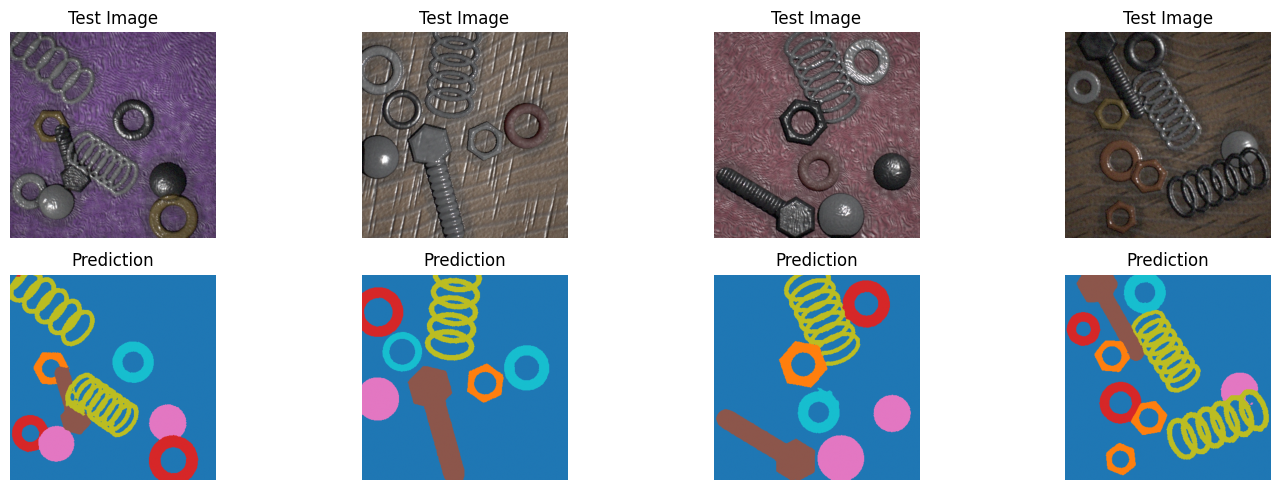

In [59]:
NUM_SAMPLES = 4

plt.figure(figsize=(15, 5))

for i in range(NUM_SAMPLES):

    image = np.array(
        Image.open(
            os.path.join(
                TEST_IMAGE_PATH,
                test_images[i]
            )
        )
    )

    plt.subplot(2, NUM_SAMPLES, i + 1)
    plt.imshow(image)
    plt.title("Test Image")
    plt.axis("off")

    plt.subplot(2, NUM_SAMPLES, NUM_SAMPLES + i + 1)
    plt.imshow(
        predicted_masks[i],
        cmap="tab10",
        vmin=0,
        vmax=6
    )
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Predictions to RLE
The trained U-Net predicts a single segmentation mask containing all seven classes.

However, the competition requires one binary mask for each foreground class.

Therefore, every predicted segmentation mask is decomposed into six binary masks, one for each mechanical component, and each binary mask is converted into Run-Length Encoding (RLE) format before creating the final submission file.

In [60]:
CLASSES = [
    "hex_nut",
    "washer",
    "bolt",
    "ball_bearing",
    "spring",
    "o_ring"
]

CLASS_ID = {
    class_name: index + 1
    for index, class_name in enumerate(CLASSES)
}

print(CLASS_ID)

{'hex_nut': 1, 'washer': 2, 'bolt': 3, 'ball_bearing': 4, 'spring': 5, 'o_ring': 6}


## Create Submission

In [61]:
submission = sample_submission.copy()

submission.head()

,ImageId_ClassId,EncodedPixels
0,img_00001.png_hex_nut,1 1
1,img_00001.png_washer,1 1
2,img_00001.png_bolt,1 1
3,img_00001.png_ball_bearing,1 1
4,img_00001.png_spring,1 1


In [62]:
rows = []

for image_name, predicted_mask in zip(test_images, predicted_masks):

    for class_name in CLASSES:

        binary_mask = (
            predicted_mask == CLASS_ID[class_name]
        )

        rows.append({
            "ImageId_ClassId": f"{image_name}_{class_name}",
            "EncodedPixels": (
                rle_encode(binary_mask)
                if binary_mask.any()
                else "1 1"
            )
        })

submission = pd.DataFrame(rows)

In [63]:
print("=" * 60)
print("SUBMISSION INFORMATION")
print("=" * 60)

print(f"Rows              : {len(submission)}")
print(f"Columns           : {submission.shape[1]}")
print(f"Missing RLE       : {submission['EncodedPixels'].isna().sum()}")

print()

display(submission.head(10))

SUBMISSION INFORMATION
Rows              : 3000
Columns           : 2
Missing RLE       : 0



,ImageId_ClassId,EncodedPixels
0,img_00001.png_hex_nut,17069 6 17451 10 17833 13 18215 18 18598 21 18...
1,img_00001.png_washer,1451 1 1827 14 2207 22 2589 27 2971 31 3353 35...
2,img_00001.png_bolt,32055 7 32436 14 32819 18 33200 27 33584 29 33...
3,img_00001.png_ball_bearing,20661 12 21042 23 21424 25 21808 28 22190 33 2...
4,img_00001.png_spring,21 28 403 30 786 31 1169 34 1551 36 1934 38 23...
5,img_00001.png_o_ring,73502 13 73883 21 74265 26 74647 30 75028 35 7...
6,img_00005.png_hex_nut,75478 7 75848 1 75851 18 76221 3 76225 29 7659...
7,img_00005.png_washer,36 71 420 71 803 73 1186 75 1570 32 1612 34 19...
8,img_00005.png_bolt,32842 2 33225 5 33608 11 33990 17 34373 21 347...
9,img_00005.png_ball_bearing,207 56 589 59 972 60 1355 62 1738 64 2122 65 2...


In [64]:
print("=" * 60)
print("FINAL SUBMISSION CHECK")
print("=" * 60)

print(submission.shape)
print(submission.isna().sum())

display(submission.head(10))

assert len(submission) == len(sample_submission)

assert submission.shape == sample_submission.shape

assert (
    submission["ImageId_ClassId"]
    ==
    sample_submission["ImageId_ClassId"]
).all()

print("Submission Verified Successfully.")

FINAL SUBMISSION CHECK
(3000, 2)
ImageId_ClassId    0
EncodedPixels      0
dtype: int64


,ImageId_ClassId,EncodedPixels
0,img_00001.png_hex_nut,17069 6 17451 10 17833 13 18215 18 18598 21 18...
1,img_00001.png_washer,1451 1 1827 14 2207 22 2589 27 2971 31 3353 35...
2,img_00001.png_bolt,32055 7 32436 14 32819 18 33200 27 33584 29 33...
3,img_00001.png_ball_bearing,20661 12 21042 23 21424 25 21808 28 22190 33 2...
4,img_00001.png_spring,21 28 403 30 786 31 1169 34 1551 36 1934 38 23...
5,img_00001.png_o_ring,73502 13 73883 21 74265 26 74647 30 75028 35 7...
6,img_00005.png_hex_nut,75478 7 75848 1 75851 18 76221 3 76225 29 7659...
7,img_00005.png_washer,36 71 420 71 803 73 1186 75 1570 32 1612 34 19...
8,img_00005.png_bolt,32842 2 33225 5 33608 11 33990 17 34373 21 347...
9,img_00005.png_ball_bearing,207 56 589 59 972 60 1355 62 1738 64 2122 65 2...


Submission Verified Successfully.


In [65]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [66]:
check = pd.read_csv("submission.csv")

print(check.shape)
print(check.isna().sum())

display(check.head())

(3000, 2)
ImageId_ClassId    0
EncodedPixels      0
dtype: int64


,ImageId_ClassId,EncodedPixels
0,img_00001.png_hex_nut,17069 6 17451 10 17833 13 18215 18 18598 21 18...
1,img_00001.png_washer,1451 1 1827 14 2207 22 2589 27 2971 31 3353 35...
2,img_00001.png_bolt,32055 7 32436 14 32819 18 33200 27 33584 29 33...
3,img_00001.png_ball_bearing,20661 12 21042 23 21424 25 21808 28 22190 33 2...
4,img_00001.png_spring,21 28 403 30 786 31 1169 34 1551 36 1934 38 23...


In [67]:
import shutil

shutil.copy(
    "best_unet_model.pth",
    "/kaggle/working/final_best_unet_model.pth"
)

print("Checkpoint saved.")

Checkpoint saved.
